In [ ]:
## **課題１**

# 授業中に紹介したSKABデータについてXGBoostを用いてモデル構築を行い，
# RandomForestの変数重要度，SHAP値と比較してどのような違いがあるか検証を行え．
# また，可能であればSVMなど他の予測モデルで予測を行った結果と比較を行い，
# 予測に効く変数が検討したモデルでどのように異なるか考察を行え．

In [2]:
%pip install xgboost
%pip install shap


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# ライブラリのインポート
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
import shap

c:\Users\yuema\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# データの読み込み
df = pd.read_csv('data/valve1.csv',)

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Accelerometer1RMS,18160.0,0.027338,0.000527,0.025553,0.026971,0.027346,0.027722,0.029031
Accelerometer2RMS,18160.0,0.040546,0.001168,0.037339,0.039761,0.040461,0.041192,0.053439
Current,18160.0,0.974279,0.273464,0.355411,0.739579,0.986835,1.202650,1.662610
Pressure,18160.0,0.063758,0.258584,-1.257000,0.054711,0.054711,0.054711,1.694350
Temperature,18160.0,70.207720,2.608980,65.188700,68.630525,69.765300,71.075925,79.889100
Thermocouple,18160.0,25.029108,0.447720,24.418700,24.674200,24.866800,25.423625,26.104400
Voltage,18160.0,230.710674,10.817408,203.135000,224.785750,230.959000,236.880500,255.324000
Volume Flow RateRMS,18160.0,31.284849,1.991965,22.000000,31.001000,32.000000,32.012600,33.969400
anomaly,18160.0,0.347412,0.476161,0.000000,0.000000,0.000000,1.000000,1.000000
changepoint,18160.0,0.003469,0.058799,0.000000,0.000000,0.000000,0.000000,1.000000


In [5]:
# 欠損値の確認
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18160 entries, 0 to 18159
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   datetime             18160 non-null  object 
 1   Accelerometer1RMS    18160 non-null  float64
 2   Accelerometer2RMS    18160 non-null  float64
 3   Current              18160 non-null  float64
 4   Pressure             18160 non-null  float64
 5   Temperature          18160 non-null  float64
 6   Thermocouple         18160 non-null  float64
 7   Voltage              18160 non-null  float64
 8   Volume Flow RateRMS  18160 non-null  float64
 9   anomaly              18160 non-null  float64
 10  changepoint          18160 non-null  float64
dtypes: float64(10), object(1)
memory usage: 1.5+ MB


In [6]:
df = df.drop(["datetime", "changepoint"], axis=1)
df

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,anomaly
0,0.026588,0.040111,1.330200,0.054711,79.3366,26.0199,233.062,32.0000,0.0
1,0.026170,0.040453,1.353990,0.382638,79.5158,26.0258,236.040,32.0000,0.0
2,0.026199,0.039419,1.540060,0.710565,79.3756,26.0265,251.380,32.0000,0.0
3,0.026027,0.039641,1.334580,0.382638,79.6097,26.0393,234.392,32.0000,0.0
4,0.026290,0.040273,1.078510,-0.273216,79.6109,26.0420,225.342,32.0000,0.0
...,...,...,...,...,...,...,...,...,...
18155,0.027605,0.039760,0.622996,0.382638,68.4247,24.4370,230.358,32.9673,0.0
18156,0.027286,0.039613,0.600692,0.054711,68.0598,24.4356,231.373,32.0000,0.0
18157,0.027203,0.041440,0.450323,0.054711,68.1836,24.4379,210.605,32.0337,0.0
18158,0.027180,0.041831,0.855527,0.382638,68.2250,24.4310,229.566,32.9673,0.0


In [7]:
# 説明変数と目的変数の分割
df_x = df.drop('anomaly', axis=1)
df_y = df.anomaly

In [8]:
# データの分割
X_train, X_test, y_train, y_test = train_test_split(df_x, df_y, test_size=0.3, random_state=42, stratify=df_y)

In [9]:
# SVM用にデータの標準化（スケーリング）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=df_x.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=df_x.columns)

In [10]:
# モデルの構築と学習

# XGBoost
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Random Forest
rf_model = RandomForestClassifier(random_state=42, max_depth=5) # 深さを制限して過学習抑制
rf_model.fit(X_train, y_train)

# SVM (RBFカーネルを使用)
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

c:\Users\yuema\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:199: UserWarning: [14:20:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [11]:
# モデルの評価 (F1 Score - Macro)
xgb_pred = xgb_model.predict(X_test)
rf_pred = rf_model.predict(X_test)
svm_pred = svm_model.predict(X_test_scaled)

print(f"XGBoost F1 Score: {f1_score(y_test, xgb_pred, average='macro'):.4f}")
print(f"Random Forest F1 Score: {f1_score(y_test, rf_pred, average='macro'):.4f}")
print(f"SVM F1 Score: {f1_score(y_test, svm_pred, average='macro'):.4f}")

XGBoost F1 Score: 0.9521
Random Forest F1 Score: 0.9031
SVM F1 Score: 0.8807


In [13]:
# 変数重要度の取得

# --- 変数重要度 (Gini / Permutation) ---
# XGBoost Feature Importance
xgb_imp = pd.Series(xgb_model.feature_importances_, index=df_x.columns).sort_values(ascending=True)

# Random Forest Feature Importance
rf_imp = pd.Series(rf_model.feature_importances_, index=df_x.columns).sort_values(ascending=True)

# SVM Permutation Importance
# SVMはfeature_importances_を持たないため、Permutation Importanceを使用
perm_importance = permutation_importance(svm_model, X_test_scaled, y_test, n_repeats=10, random_state=42)
svm_imp = pd.Series(perm_importance.importances_mean, index=df_x.columns).sort_values(ascending=True)

In [14]:
# SHAP値の計算

# XGBoost
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_test)

# Random Forest
explainer_rf = shap.TreeExplainer(rf_model)
shap_values_rf = explainer_rf.shap_values(X_test)
# RFのSHAPはクラスごとのリストで返るため、異常クラス(1)側を取得
if isinstance(shap_values_rf, list):
    shap_values_rf = shap_values_rf[1]

In [15]:
# SVM (KernelExplainerを使用 - 計算コストが高いためデータの一部を使用)
# 背景データとして訓練データの一部（kmeansで要約）を使用
X_train_summary = shap.kmeans(X_train_scaled, 10)
explainer_svm = shap.KernelExplainer(svm_model.predict, X_train_summary)
shap_values_svm = explainer_svm.shap_values(X_test_scaled)

100%|██████████| 5448/5448 [43:33<00:00,  2.08it/s] 


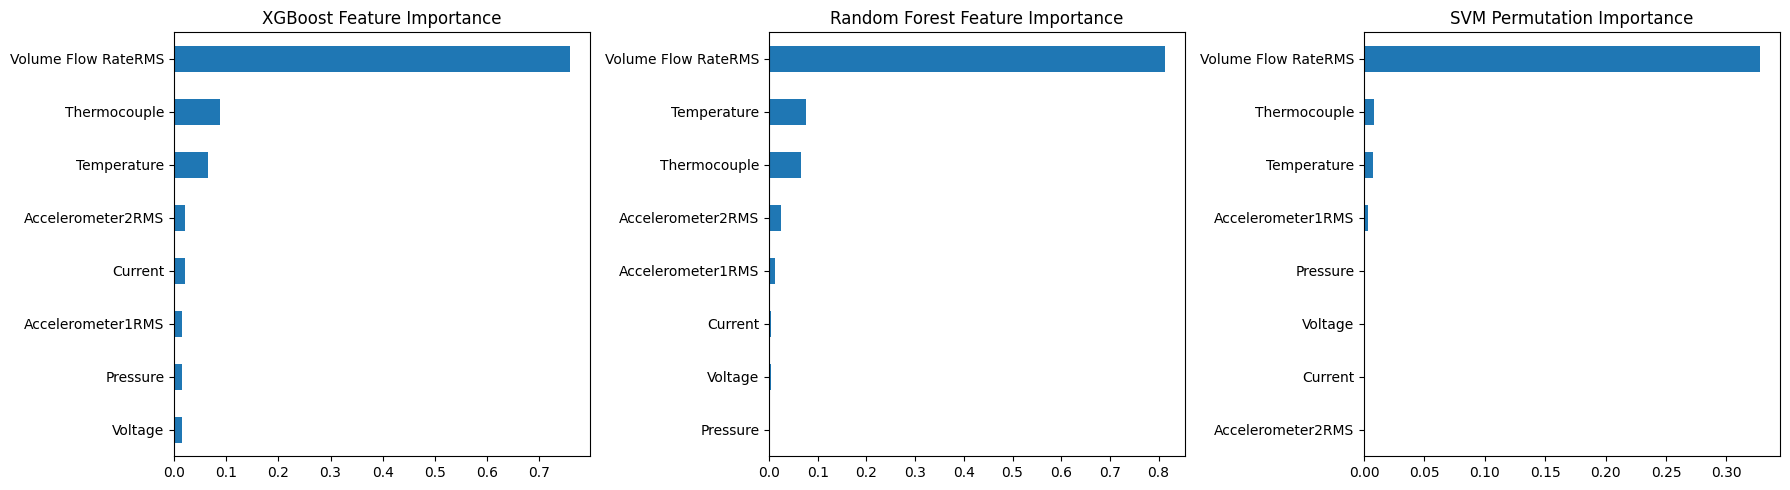

In [16]:
# 可視化
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

xgb_imp.plot(kind='barh', ax=axes[0], title='XGBoost Feature Importance')
rf_imp.plot(kind='barh', ax=axes[1], title='Random Forest Feature Importance')
svm_imp.plot(kind='barh', ax=axes[2], title='SVM Permutation Importance')

plt.tight_layout()
plt.show()

XGBoost SHAP Summary


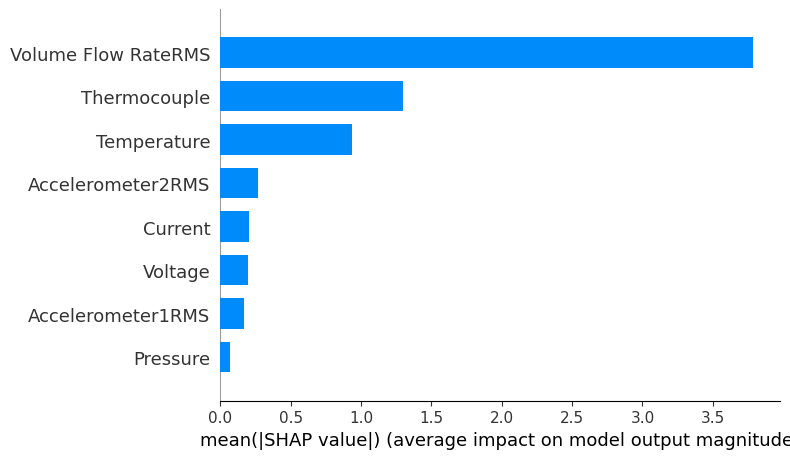

Random Forest SHAP Summary


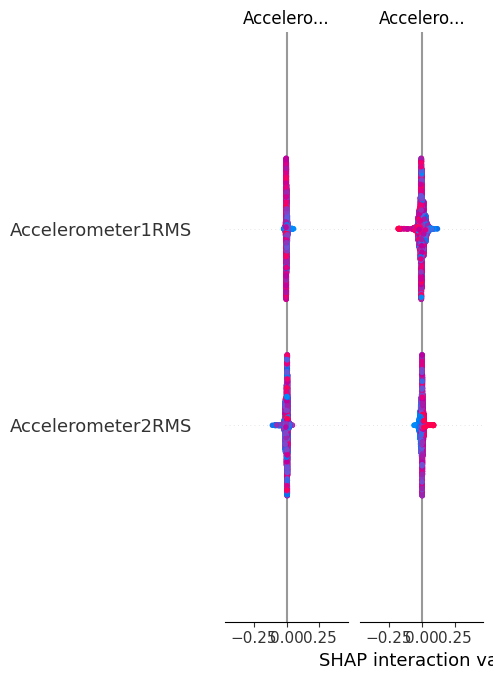

SVM SHAP Summary


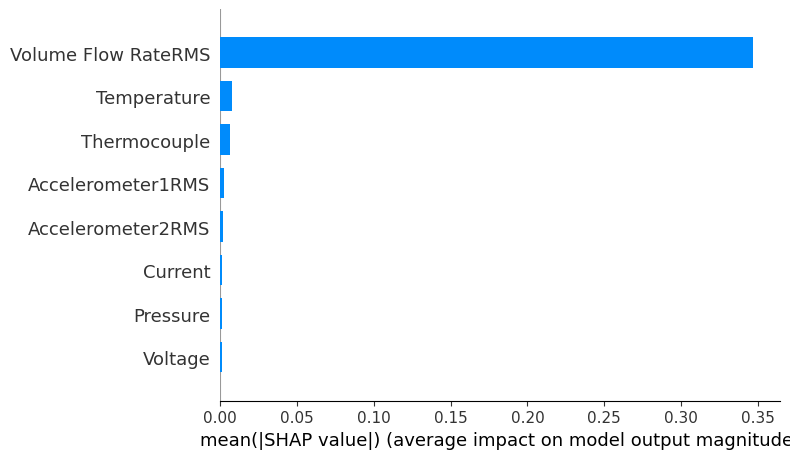

In [17]:
# SHAP Summary Plots
print("XGBoost SHAP Summary")
shap.summary_plot(shap_values_xgb, X_test, plot_type="bar")
print("Random Forest SHAP Summary")
shap.summary_plot(shap_values_rf, X_test, plot_type="bar")
print("SVM SHAP Summary")
shap.summary_plot(shap_values_svm, X_test_scaled_df, plot_type="bar")